# **Naira to Dollar Exchange Rate Forecast**

This notebook presents a data-driven approach to forecasting the Nigeria–US forex rate using historical time series data. The workflow combines exploratory data analysis (EDA), feature engineering, and machine learning / deep learning models to uncover trends, seasonality, and volatility patterns inherent in the exchange rate movements.

Specifically, the notebook will:

 - Explore the data – assess trends, stationarity, seasonality, and volatility in the forex series.

 - Engineer predictive features – such as lag values, rolling statistics, differencing, and external indicators (if available).

By the end of this notebook, we aim to generate data capable of producing accurate, explainable, and adaptive predictions of the NGN/USD exchange rate

In [48]:
# import required pacakges
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

### **Data Exploration**

In [26]:
# load data
data = pd.read_csv('../data/01_raw/ngn_us_exchange_rates.csv')

# display data
data.head()

,Date,Rate
0,2025-10-23,1461.88
1,2025-10-22,1463.45
2,2025-10-21,1465.04
3,2025-10-20,1465.77
4,2025-10-19,1468.99


In [27]:
# check the dimensions of the data
n_rows, n_cols = data.shape
print(f'There are {n_rows:,} datapoints and {n_cols} variables in the dataset')

There are 7,876 datapoints and 2 variables in the dataset


In [28]:
# check the variables in the dataset
print(f'The variables in the dataset are:')
list(data.columns)

The variables in the dataset are:


['Date', 'Rate']

In [29]:
# check data information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7876 entries, 0 to 7875
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    7876 non-null   object 
 1   Rate    7876 non-null   float64
dtypes: float64(1), object(1)
memory usage: 123.2+ KB


In [30]:
# Show basic statistics of numerical variables
data['Rate'].describe().transpose()

count    7876.000000
mean      276.461856
std       338.614186
min        73.100000
25%       118.000000
50%       152.000000
75%       305.757500
max      1681.390000
Name: Rate, dtype: float64

## **Understanding the Basic Statistics**

The basic statistics reveal three major properties of your data that are crucial for choosing and building a model: **Non-Stationarity, High Volatility, and Strong Skewness.**

### **1. Strong Positive Skewness and Tail Risk**

* **Observation:** The **Median ($\text{NGN } 152$) is much lower than the Mean ($\text{NGN } 276.5$)**, and the $75\%$ quartile ($\text{NGN } 305.76$) is nowhere near the Max ($\text{NGN } 1681.39$). This shows that the data is **heavily skewed** toward the lower values, with a long, fat tail representing the recent, extreme high rates.
* **Modeling Meaning:**
    * **Avoid Simple Averages:** Models based on simple means (like simple moving averages) will be highly misleading.
    * **Data Transformation:** Consider **log-transforming** the data. This often reduces the skewness and can stabilize the variance, making the time series easier to model with standard techniques (like ARIMA).

### **2. Evidence of Non-Stationarity**

* **Observation:** The enormous gap between the $75\%$ value ($\text{NGN } 305.76$) and the $\text{Max}$ value ($\text{NGN } 1681.39$) strongly suggests that the **statistical properties of the series have changed drastically over time**. The process generating the early data (stable, low rates) is fundamentally different from the process generating the recent data (high, volatile rates).
* **Modeling Meaning:**
    * **Differencing is Necessary:** Your series is almost certainly **non-stationary** (it has a strong trend). You will need to **difference** the data (i.e., model the change in rate, not the rate itself) to use traditional time-series models like ARIMA.
    * **Structural Breaks:** This data likely contains **structural breaks** (major, permanent shifts in the mean and variance). Advanced modeling techniques, such as incorporating a **change-point detection** or modeling the periods separately, might be required.

### **3. Extremely High Volatility**

* **Observation:** The **Standard Deviation is greater than the Mean**, indicating that volatility is a major feature of this data, especially the recent period.
* **Modeling Meaning:**
    * **ARCH/GARCH Models:** Since high returns (or depreciation, in this case) tend to be followed by more high-volatility moves, we should consider using **volatility-modeling techniques** like **ARCH** (Autoregressive Conditional Heteroskedasticity) or **GARCH** (Generalized ARCH) alongside mean-forecasting model (like ARIMA). This is essential for accurately forecasting the **risk** or uncertainty around your predicted exchange rate.

In essence, the basic statistics warn you against using simple models and confirm that you must account for **trend, non-linear growth, and highly volatile, non-normal residuals** for successful forecasting.

In [31]:
# Convert transaction_time column to date format
data["Date"] = pd.to_datetime(data["Date"], errors="coerce")

start_date = data['Date'].min()
end_date = data['Date'].max()
# Verify date range
print(
    f"FX period covers {start_date.date()} → {end_date.date()}"
)

FX period covers 1995-07-11 → 2025-10-23


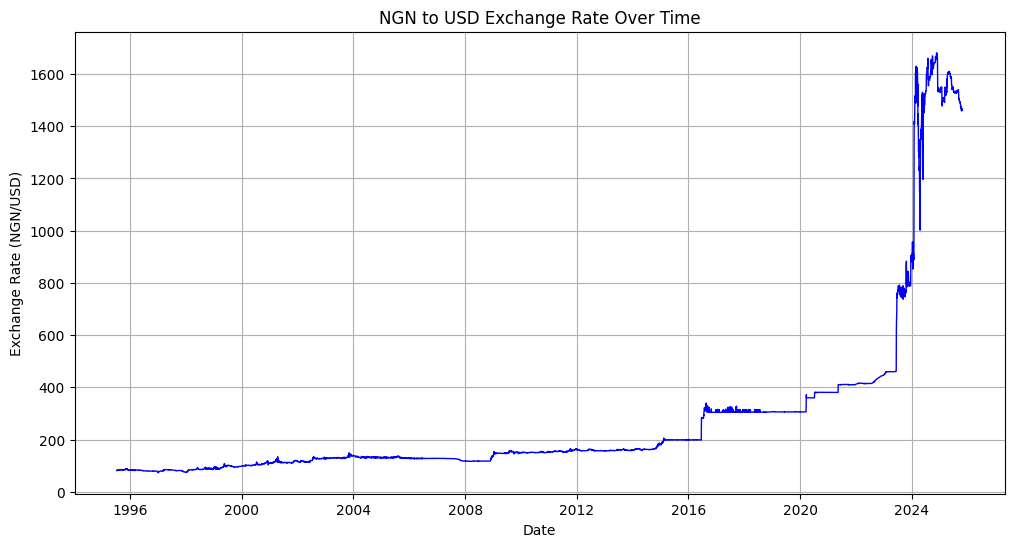

In [32]:
# plot the exchange rate over time
plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Rate'], color='blue', linewidth=1)
plt.title('NGN to USD Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (NGN/USD)')
plt.grid(True)
plt.show()

In [33]:
# Resample to daily 
# forward-fill to ensure continuous index for feature generation
df = data.set_index('Date').asfreq('D')
df['Rate'] = df['Rate'].ffill()

In [34]:
# Save cleaned data
os.makedirs('../data/02_processed/', exist_ok=True)
df.reset_index().to_csv('../data/02_processed/ngn_us_exchange_rates_cleaned.csv', index=False)

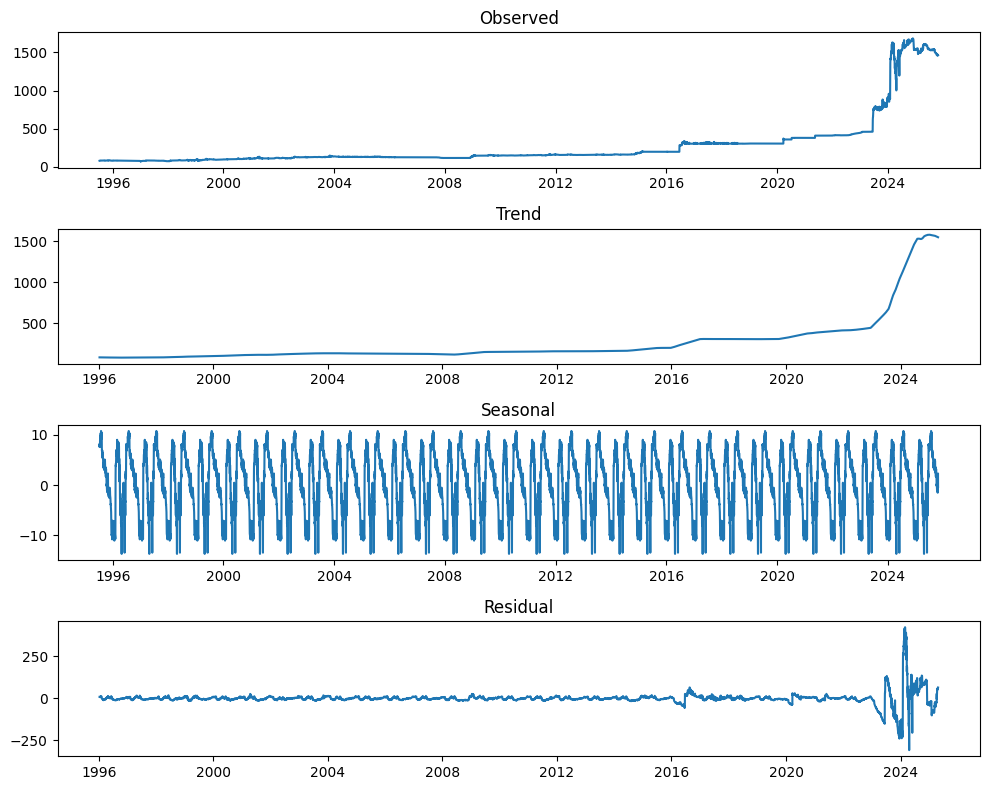

In [35]:
# Decompose the time series to observe trend, seasonality, and residuals
decomposition = seasonal_decompose(df['Rate'], model='additive', period=365)
plt.figure(figsize=(10,8))
plt.subplot(411)
plt.plot(decomposition.observed)
plt.title('Observed')
plt.subplot(412)
plt.plot(decomposition.trend)
plt.title('Trend')
plt.subplot(413)
plt.plot(decomposition.seasonal)
plt.title('Seasonal')
plt.subplot(414)
plt.plot(decomposition.resid)
plt.title('Residual')
plt.tight_layout()
plt.show()

The plot illustrates the historical **Exchange Rate (NGN/USD)**, showing the amount of **Nigerian Naira (NGN) required to purchase one US Dollar (USD)** from mid 1995 to late 2025.

Here are the most significant observations:

---

## **Long-Term Trend: Steady Depreciation**

The overarching trend is one of **massive and accelerating depreciation** of the Naira against the US Dollar over the entire period.

* **1996 to ~2015:** The exchange rate was relatively stable, gradually climbing from around $\text{NGN } 80/\text{USD}$ to $\text{NGN } 200/\text{USD}$.
* **Post-2015/2016:** A clear, more aggressive depreciation begins, with the rate climbing to around $\text{NGN } 300-\text{NGN } 350/\text{USD}$ and remaining in a band for a few years.
* **Pre-2023:** The rate continues its steady, upward climb, breaching the $\text{NGN } 400/\text{USD}$ mark and approaching $\text{NGN } 500/\text{USD}$.

---

## **Extreme Recent Volatility and Depreciation**

The most striking feature is the dramatic change in the final two years of the plot (from mid-2023 onwards).

* **Sharp Breakout (Mid-2023):** The rate breaks decisively above the long-held $\text{NGN } 400-\text{NGN } 500/\text{USD}$ range and rises sharply towards the $\text{NGN } 800/\text{USD}$ level.
* **Hyper-Depreciation (2024 - 2025):** The plot shows a near-vertical surge, with the exchange rate skyrocketing **above $\text{NGN } 1600/\text{USD}$**. This represents an unprecedented period of volatility and rapid loss of value for the Naira.
* **Current Rate:** The plot ends with the rate having pulled back slightly from its peak, hovering around the $\text{NGN } 1400 - \text{NGN } 1500/\text{USD}$ level, but still extremely high relative to its historical values.

---


## **Seasonal Component**

This plot shows a clear, **regular, and repeating pattern** that occurs at fixed intervals, independent of the overall trend.

* **Observation:** The Seasonal component exhibits a strong, consistent wave-like pattern across the entire dataset (1996 to present). The amplitude (height) of these waves is relatively consistent, oscillating between approximately $\text{+10}$ and $\text{-10}$ NGN/USD.
* **Meaning:** This suggests that the NGN/USD exchange rate has a **predictable, recurring cycle** within a year (or some other fixed period). This is likely due to regular, calendar-driven events, such as:
    * Quarterly/Year-end **corporate demand** for foreign exchange.
    * Seasonal changes in **remittances** or **oil exports**.
    * **Fiscal calendar** effects or policy actions that occur at specific times of the year.

## **Residual Component**

The Residual component is what is **left over** after the Trend and Seasonal patterns are removed from the Observed data. It represents the **unexplained noise**, sudden shocks, or irregular movements.

* **Observation (1996 to ~2023):** For most of the time series, the residual is flat, centered near zero, and very small (mostly within a range of $\text{-50}$ to $\text{+50}$). This indicates that the **Trend and Seasonal components did a good job** of explaining the historical rate movements.
* **Observation (2023 Onwards):** There is a massive spike in the residual around 2023–2024. The residual values swing wildly, reaching as high as $\text{+250}$ and as low as $\text{-250}$.
* **Meaning:** The sharp increase and volatility in the Residual component post-2023 means that the recent extreme movements in the exchange rate **cannot be fully explained** by either the long-term trend or the regular seasonal patterns. This sudden jump in "unexplained" variation is a strong indicator of **major, sudden, non-periodic structural changes or shocks** in the market, such as:
    * **Major policy shifts** (e.g., currency market liberalization).
    * Unforeseen **economic crises** or global events.
    * **Market panic** or large, one-time interventions.

---

##  **Implications for Modeling**

The decomposition provides crucial insights for choosing and implementing an appropriate forecasting model:

| Component | Modeling Implication |
| :--- | :--- |
| **Trend** (Aggressive 2023+ rise) | An effective model **must be able to capture non-linear, accelerating growth**. Simple linear models will fail. ARIMA or Exponential Smoothing models may struggle to adapt to the recent explosive change without external variables. |
| **Seasonal** (Strong, consistent cycle) | The model **must include a seasonal term** (e.g., using a **Seasonal ARIMA** or **SARIMA** model) to exploit this predictable pattern and improve forecast accuracy. |
| **Residual** (Large 2023+ spikes) | The large, recent residual spikes indicate that the rate is now being driven by **factors outside of the time series itself**. A purely time-series-based model (like SARIMA) will have high error in this period. Therefore, we would consider a **multi-variate model** (e.g., an **ARIMAX/SARIMAX** model) that incorporates **Exogenous Variables** (external factors) such as:
    * Oil Prices
    * Inflation Rates
    * Monetary Policy Rates (Interest rates) |

**In summary, the plot illustrates a gradual weakening of the Naira over two decades, followed by a sudden and massive collapse in its value against the US Dollar in the most recent period (2023–2025).**

In [36]:
# Resample the 'Rate' column to weekly frequency, using the last value of the week (Friday close)
df_weekly = df['Rate'].resample('W-FRI').last()
df_weekly = df_weekly.to_frame()

In [37]:
#Test for stationarity
# Augmented Dickey Fuller test
result = adfuller(df_weekly['Rate'].dropna())
pvalue = result[1]
if pvalue < 0.05:
    print(f'p-value: {pvalue} - stationary')
else:
    print(f'p-value: {pvalue} - not stationary')

p-value: 0.9979097678495158 - not stationary


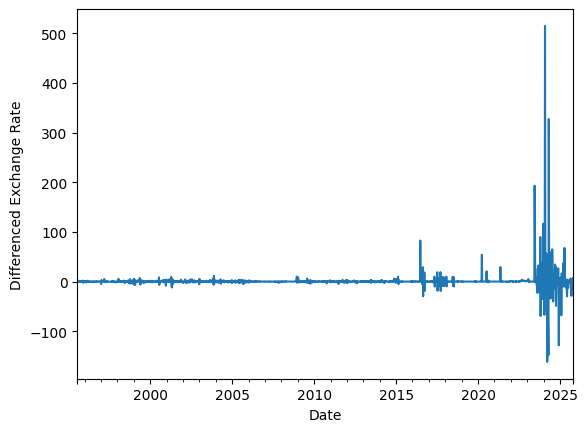

In [38]:
# Difference the data
# To deal with non-stationarity
differenced_data = df_weekly['Rate'].diff().dropna()
# Plot the differenced data
ax = differenced_data.plot()
ax.set_ylabel('Differenced Exchange Rate')
plt.show()

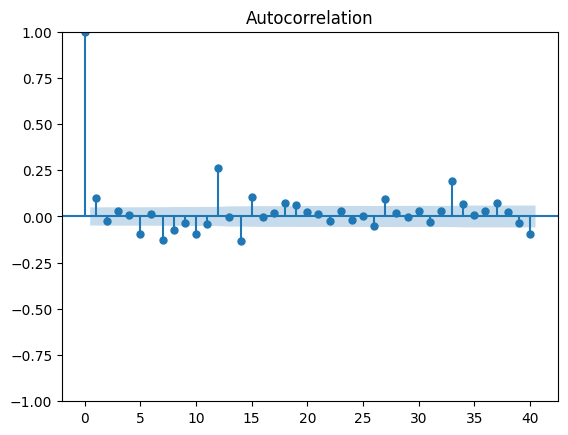

In [49]:
# Autocorrelation of the differenced data
plot_acf(differenced_data, lags=40)
plt.show()

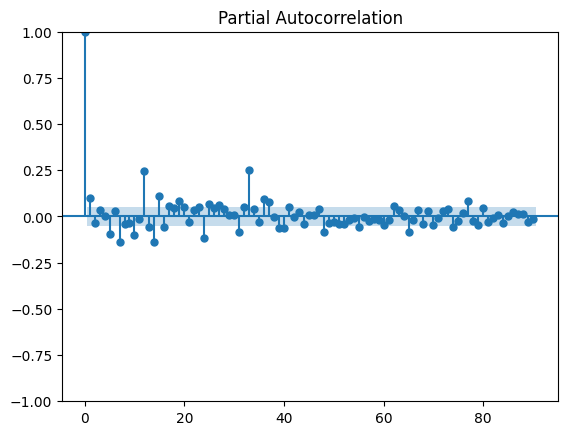

In [39]:
# Partial autocorrelation of the differenced data
plot_pacf(differenced_data, lags = 90)
plt.show()

## **PACF Plot Analysis**

The PACF measures the correlation between a time series and its own lagged values, **after accounting for the correlations at all intermediate lags.**

### What We Observe:

* **Lag 1 Spike:** This is as expected. thr value for time t is mostly related to the value in the immediate previous timestep (t+1).
* **Significant Lags:** The only other lags that clearly exceed the blue shaded region (the **significance bounds**) are at **Lag 1, 2, 6, 8, 11, 13, 15, 16, 25, 32, 34**

    * **Lag 2,3, 4, 8, 9, 12:** These small, yet significant, spikes might indicate a short-term (daily, weekly orbi weekly) dependencies or a moving average component.
    * **Lag 31, 40, 52, 53, 60, 70, 80, 89:** These spikes could point to a **monthly or seasonal pattern**.


### **Feature Engineering**

**Lags, Rolling stats, Returns, Calendar**

In [40]:
df_feat = df_weekly.copy()

In [41]:
# get differenced series
df_feat['diff'] = df['Rate'].diff()

# get lags 1..14
for lag in [1, 2, 6, 8, 11, 13, 15, 16, 25, 32, 34]:
    df_feat[f'lag_{lag}'] = df_feat['diff'].shift(lag)

In [42]:
# rolling means and std
for window in [4, 8, 12]:
    df_feat[f'rmean_{window}'] = df_feat['diff'].rolling(window).mean().shift(1)
    df_feat[f'rstd_{window}'] = df_feat['diff'].rolling(window).std().shift(1)

In [43]:
# returns
for diff in [3, 7, 14, 21, 30, 60, 90]:
    df_feat[f'ret_{diff}'] = df_feat['diff'].pct_change(diff)

/var/folders/rh/bvr0p9hd7sg3x6qmjpjfst0c0000gn/T/ipykernel_12309/452080351.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_feat[f'ret_{diff}'] = df_feat['diff'].pct_change(diff)
/var/folders/rh/bvr0p9hd7sg3x6qmjpjfst0c0000gn/T/ipykernel_12309/452080351.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_feat[f'ret_{diff}'] = df_feat['diff'].pct_change(diff)
/var/folders/rh/bvr0p9hd7sg3x6qmjpjfst0c0000gn/T/ipykernel_12309/452080351.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading

In [44]:
# calendar features
df_feat = df_feat.reset_index().rename(columns={'index':'Date'})
df_feat['month'] = df_feat['Date'].dt.month
df_feat['day'] = df_feat['Date'].dt.day
df_feat['year'] = df_feat['Date'].dt.year


In [45]:
# Drop initial NaNs after lagging
df_feat = df_feat.dropna().reset_index(drop=True)

In [46]:
# Display the feature engineered data
df_feat.head()

,Date,Rate,diff,lag_1,lag_2,lag_6,lag_8,lag_11,lag_13,lag_15,...,ret_3,ret_7,ret_14,ret_21,ret_30,ret_60,ret_90,month,day,year
0,1997-04-11,84.66,-0.29,0.00,0.00,-0.040,0.000,0.08,1.24,-0.22,...,-3.685185,-inf,-0.879167,-1.973154,-6.800000,-0.768000,-1.58,4,11,1997
1,1997-05-02,85.05,0.25,0.00,0.00,0.108,0.560,0.00,0.06,0.30,...,-1.862069,-0.722222,2.125000,-7.250000,inf,-1.297619,inf,5,2,1997
2,1997-05-09,84.48,-0.32,0.25,0.00,0.000,0.900,0.00,0.00,0.08,...,-inf,-3.962963,-6.333333,-inf,0.454545,-1.780488,-1.80,5,9,1997
3,1997-05-16,84.48,0.02,-0.32,0.25,0.000,0.108,-0.04,0.00,0.06,...,inf,inf,inf,-1.909091,-0.600000,-0.900000,-0.96,5,16,1997
4,1997-05-23,84.96,0.41,0.02,-0.32,-0.290,0.000,0.56,0.00,0.00,...,0.640000,inf,inf,-2.863636,-1.745455,inf,inf,5,23,1997


In [47]:
# Save the feature engineered data
os.makedirs('../data/03_features/', exist_ok=True)
df_feat.to_csv('../data/03_features/ngn_us_exchange_rates_features.csv', index=False)